In [1]:
import pyodbc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cnxn = pyodbc.connect('DSN=Hermes_DSN',autocommit=True)
cursor = cnxn.cursor()

# prep

In [2]:
# Data prep
query = f"""

SELECT security_isin
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state f
WHERE security_type IN ('GOVS', 'FIDE')
AND assttp_scty_issr_sector_riad = 'S1311'
AND business_date >= '2023-01-01' 
AND gnlcoll = 'SPEC'
GROUP BY security_isin
HAVING COUNT(DISTINCT security_type) = 2

"""

govs = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\2371169088.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  govs = pd.read_sql_query(query, cnxn)


In [3]:
unique_govs = tuple(govs['security_isin'])

In [4]:
ust = pd.read_csv('Data\\TreasuryCusip.csv')

In [5]:
treasuries = tuple(ust['ISIN'].unique())

In [6]:
# Data prep
query = f"""

SELECT
  CASE WHEN borrower_id < lender_id THEN borrower_id ELSE lender_id END AS a,
  CASE WHEN borrower_id < lender_id THEN lender_id ELSE borrower_id END AS b
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
WHERE intragroup = 1
GROUP BY
  CASE WHEN borrower_id < lender_id THEN borrower_id ELSE lender_id END,
  CASE WHEN borrower_id < lender_id THEN lender_id ELSE borrower_id END;


"""

df_edges = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\143588195.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_edges = pd.read_sql_query(query, cnxn)


In [7]:
import pandas as pd

# edges: columns ['a','b']
edges = df_edges.values.tolist()

parent = {}
rank = {}

def find(x):
    if parent.setdefault(x, x) != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(x, y):
    rx, ry = find(x), find(y)
    if rx == ry: return
    rxr, ryr = rank.setdefault(rx,0), rank.setdefault(ry,0)
    if rxr < ryr:
        parent[rx] = ry
    elif rxr > ryr:
        parent[ry] = rx
    else:
        parent[ry] = rx
        rank[rx] = rxr + 1

for a,b in edges:
    union(a,b)

# canonical id = min-LEI per component (stable label)
from collections import defaultdict
comps = defaultdict(list)
for x in parent.keys():
    comps[find(x)].append(x)

canon = {rep: min(members) for rep, members in comps.items()}
mapping = []
for x in parent.keys():
    rep = find(x)
    mapping.append((x, canon[rep]))

df_mapping_cc = pd.DataFrame(mapping, columns=["lei","group_id_synth"]).sort_values(["group_id_synth","lei"])


In [8]:
foreign_bg = ('0W1U67PTV5WY3WYWKD79',
'2138008P9NOMBRMROI73',
'213800A9GT65GAES2V60',
'213800G8QEXN34A2YG53',
'213800GVD8L87R18CT98',
'213800IBT39XQ9C4CP71',
'213800NW35DTWHTMX505',
'213800RZ3GCUXMBGYN59',
'2IGI19DL77OX0HC3ZE78',
'4PQUHN3JPFGFNF3BB653',
'4ZHCHI4KYZG2WVRT8631',
'5299007QVIQ7IO64NX37',
'5493000IQQ05Y25L0V92',
'5493000YPN33HF74SN02',
'54930010P7BUGOECPI58',
'5493002XYZZ0CGQ6CB58',
'54930040QPHHWGT1J432',
'54930050SE0SM7CM2G07',
'5493006PWI2H6PX25403',
'5493007VSMFZCPV1NB83',
'5493008GNQHVI377MY19',
'5493009NLZXZGJDOPC94',
'549300BKWHXYEXPV0328',
'549300FH0WJAPEHTIQ77',
'549300HU9EWFS3CNX640',
'549300KP56LL8NKKFL47',
'549300RSY622D5TQWS42',
'549300SXSTGQY3EA1B18',
'549300WDT1HWUMTUW770',
'571474TGEMMWANRLN572',
'724500AAT1DK36059L16',
'9676007O0UF5YB3QPR03',
'BWS7DNS2Z4NPKPNYKL75',
'HV5W8PGLJ127N2SFSM23'
)

In [9]:
euro_area_bg = ('0IKLU6X1B10WK7X42C15',
'1VUV7VQFKUOQSJ21A208',
'2138001YBO7CJNQOEE37',
'21380027LW8AF6I1WA03',
'2138003Z5ZVN16GFYV70',
'2138004VZX8CSGPTDX68',
'21380073P7J4PAD91E29',
'213800AGKVL18YKQSV51',
'213800BWHAS44J2C1B28',
'213800D4LHBCXXEEE235',
'213800DBQIB6VBNU5C64',
'213800FKGFR7Q2ACLS83',
'213800G63T4ER4MSVR22',
'213800HV6TP2I5A6MW58',
'213800I92TAU7I3FP232',
'213800KGF4EFNUQKAT69',
'213800OOQOSULB37T658',
'213800ZIGVOZ992FNQ85',
'222100D7H9VRJEH7DU25',
'222100M2PU043YB7YQ06',
'23B6332KMR0JIZLJG565',
'2534006G7F7F1TFC9T77',
'2534006HF1L4YF10UD91',
'253400N2R0RF14JQ0060',
'2549002MVYWWDX54IB83',
'259400QHDOZWMJ103294',
'259400YLRTOBISHBVX41',
'2W8N8UU78PMDQKZENC08',
'31570010000000036567',
'315700GBLUBZ50S45F53',
'315700GXRKZ452JF2U13',
'3M5E1GQGKL17HI6CPN30',
'3U8WV1YX2VMUHH7Z1Q21',
'48510000156ESYOBV122',
'52965FONQ5NZKP0WZL45',
'52990002O5KK6XOGJ020',
'52990010C4NK412ZL440',
'5299004TE2DYMKEAM814',
'5299005UJX6K7BQKV086',
'52990080NNXXLC14OC65',
'529900AQBND3S6YJLY83',
'529900C214QOT3ZYD838',
'529900C4RSSBWXBSY931',
'529900E1WHT64CB20277',
'529900FWTU88V844B672',
'529900GGYMNGRQTDOO93',
'529900K16YGKC8BES892',
'529900T32UL0CP1FZA06',
'529900UKZBMDBDZIXD62',
'529900VA5CNBWXAONR25',
'549300298FD7AS4PPU70',
'54930056IRBXK0Q1FP96',
'549300685QG7DJS55M76',
'5493007RT80TMKY7TO30',
'549300ABE4K96QOCEH37',
'549300CQ9NLEHMRCU505',
'549300DV870NBWY5W279',
'549300DY78U4CMKNHE48',
'549300DYPOFMXOR7XM56',
'549300FOF121DSRG5867',
'549300FR956J8UJDWQ78',
'549300GOF5A5DHWJLV03',
'549300GRXFI7D6PNEA68',
'549300L7YCATGO57ZE10',
'549300LYFYVPUCG6SY25',
'549300NC3SZTETC10349',
'549300NEBDPH0ZXIF850',
'549300Z6OB1D4ZUBD145',
'63540061DPCBNMCGRY22',
'635400CE9HHFB55PEY43',
'635400GQWXFJDCQXW612',
'635400LNHEPZBRNB5D58',
'635400LRAHYBRUZCIH13',
'724500A11NIP5HCVF984',
'815600154F8F91CF6B05',
'8156002070DA4DCBFF31',
'81560027D07F9BDB8436',
'81560038903FF9FA8F80',
'815600522538355AE429',
'8156007395B20763EB44',
'8156009F40F6523F7022',
'815600A32DA05F693F24',
'8EFE15WY4PBBKG6GZI21',
'95980020140005184148',
'9598009X93GQBNHF1L85',
'959800T0J9ADL4GYSS41',
'9695000O0HNLFNR0FB30',
'969500DCEVPV6UIYK220',
'969500QLO3GN6GUB4P61',
'FI6C7E5PBUB3F9K43B44',
'GP5DT10VX1QRQUKVBK64',
'J4CP7MHCXR8DAQMKIL78',
'NNVPP80YIZGEY2314M97',
'RRAN7P32P0W0YY4XQW79',
'SI5RG2M0WQQLZCXKRM20'
)

In [10]:
bgroups = tuple(set(foreign_bg + euro_area_bg))

In [11]:
foreign_entity = tuple(df_mapping_cc.loc[df_mapping_cc['group_id_synth'].isin(foreign_bg), 'lei'].unique())
euro_area_entity = tuple(df_mapping_cc.loc[df_mapping_cc['group_id_synth'].isin(euro_area_bg), 'lei'].unique())

# Branch-Subsidiary

In [ ]:
query = f"""

SELECT 
  CASE
    WHEN s.lender_country_residence IN ('US') THEN 'US'
    WHEN s.lender_country_residence IN ('GB') THEN 'UK'
    WHEN s.lender_country_residence IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS residence_group,
  CASE
    WHEN s.lender_country IN ('US') THEN 'US'
    WHEN s.lender_country IN ('GB') THEN 'UK'
    WHEN s.lender_country IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS country_group,
  SUM(nominal_value) AS lending
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
WHERE s.business_date BETWEEN '2021-07-04' AND '2025-07-01'
  AND nominal_ccy = 'USD'
  AND intragroup = 1
  AND central_clearing = 'non-cleared'
  AND security_isin IN {treasuries}
  AND gnlcoll = 'SPEC'
GROUP BY residence_group, country_group
  
"""

df_lend = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\1312749211.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lend = pd.read_sql_query(query, cnxn)


In [ ]:
query = f"""

SELECT 
  CASE
    WHEN s.borrower_country_residence IN ('US') THEN 'US'
    WHEN s.borrower_country_residence IN ('GB') THEN 'UK'
    WHEN s.borrower_country_residence IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS residence_group,
  CASE
    WHEN s.borrower_country IN ('US') THEN 'US'
    WHEN s.borrower_country IN ('GB') THEN 'UK'
    WHEN s.borrower_country IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS country_group,
  SUM(nominal_value) AS borrowing
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
WHERE s.business_date BETWEEN '2021-07-04' AND '2025-07-01'
  AND nominal_ccy = 'USD'
  AND intragroup = 1
  AND central_clearing = 'non-cleared'
  AND security_isin IN {treasuries}
  AND gnlcoll = 'SPEC'
GROUP BY residence_group, country_group
  
"""

df_borr = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\3112730896.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borr = pd.read_sql_query(query, cnxn)


In [16]:
df = df_lend.merge(df_borr, on=['residence_group', 'country_group'], how='outer').fillna(0)

In [17]:
# Branch vs subsidiary
df['entity_type'] = np.where(df['residence_group'] == df['country_group'], 'Subsidiary', 'Branch')

# Gross volume
df['gross'] = df['lending'] + df['borrowing']

# Percentage within each residence group
df['pct'] = df.groupby('residence_group')['gross'].transform(lambda x: x / x.sum() * 100)

In [18]:
# Summary
print(df.groupby(['residence_group', 'entity_type'])['pct'].sum().round(1))

residence_group  entity_type
Euro Area        Subsidiary     100.0
Other            Branch          31.4
                 Subsidiary      68.6
UK               Branch          96.0
                 Subsidiary       4.0
US               Branch          16.3
                 Subsidiary      83.7
Name: pct, dtype: float64


In [ ]:
query = f"""

SELECT 
  CASE
    WHEN s.lender_country_residence IN ('US') THEN 'US'
    WHEN s.lender_country_residence IN ('GB') THEN 'UK'
    WHEN s.lender_country_residence IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS residence_group,
  CASE
    WHEN s.lender_country IN ('US') THEN 'US'
    WHEN s.lender_country IN ('GB') THEN 'UK'
    WHEN s.lender_country IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS country_group,
  SUM(nominal_value) AS lending
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
WHERE s.business_date BETWEEN '2021-07-04' AND '2025-07-01'
  AND nominal_ccy = 'EUR'
  AND intragroup = 1
  AND central_clearing = 'non-cleared'
  AND (
    (s.security_type = 'GOVS'
     AND LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.assttp_scty_issr_sector_riad = 'S1311')
    OR
    (LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.security_isin IN {unique_govs})
  )
GROUP BY residence_group, country_group
  
"""

df_lend = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\2160714054.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lend = pd.read_sql_query(query, cnxn)


In [ ]:
query = f"""

SELECT 
  CASE
    WHEN s.borrower_country_residence IN ('US') THEN 'US'
    WHEN s.borrower_country_residence IN ('GB') THEN 'UK'
    WHEN s.borrower_country_residence IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS residence_group,
  CASE
    WHEN s.borrower_country IN ('US') THEN 'US'
    WHEN s.borrower_country IN ('GB') THEN 'UK'
    WHEN s.borrower_country IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS country_group,
  SUM(nominal_value) AS borrowing
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
WHERE s.business_date BETWEEN '2021-07-04' AND '2025-07-01'
  AND nominal_ccy = 'EUR'
  AND intragroup = 1
  AND central_clearing = 'non-cleared'
  AND (
    (s.security_type = 'GOVS'
     AND LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.assttp_scty_issr_sector_riad = 'S1311')
    OR
    (LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.security_isin IN {unique_govs})
  )
GROUP BY residence_group, country_group
  
"""

df_borr = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\879299819.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borr = pd.read_sql_query(query, cnxn)


In [21]:
df = df_lend.merge(df_borr, on=['residence_group', 'country_group'], how='outer').fillna(0)

In [22]:
# Branch vs subsidiary
df['entity_type'] = np.where(df['residence_group'] == df['country_group'], 'Subsidiary', 'Branch')

# Gross volume
df['gross'] = df['lending'] + df['borrowing']

# Percentage within each residence group
df['pct'] = df.groupby('residence_group')['gross'].transform(lambda x: x / x.sum() * 100)

In [23]:
# Summary
print(df.groupby(['residence_group', 'entity_type'])['pct'].sum().round(1))

residence_group  entity_type
Euro Area        Subsidiary     100.0
Other            Subsidiary     100.0
UK               Branch           7.9
                 Subsidiary      92.1
US               Branch           3.6
                 Subsidiary      96.4
Name: pct, dtype: float64


# Market clearing structure

## EUR

In [12]:
# Data prep
query = f"""
WITH daily as (
SELECT business_date, central_clearing, sum(nominal_euro) as volume, 
SUM(
CASE 
    WHEN s_lender.sector = 'BANK' AND s_borrower.sector = 'BANK' AND intragroup = 0 THEN nominal_euro
    ELSE 0
END) as interbank_share,
SUM(CASE 
    WHEN intragroup = 1 THEN nominal_euro
    ELSE 0 
END)AS intra_share
FROM xlab_ecb_prj_sftds_cb_common.hermesf_flow f
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON f.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON f.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date > '2021-01-04' AND business_date <= '2025-07-01'
AND (
    (f.security_type = 'GOVS'
     AND LEFT(f.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND f.gnlcoll = 'SPEC'
     AND f.assttp_scty_issr_sector_riad = 'S1311')
    OR
    (LEFT(f.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND f.gnlcoll = 'SPEC'
     AND f.security_isin IN {unique_govs})
  )
GROUP BY business_date, central_clearing
)

SELECT central_clearing, ROUND(avg(volume)/1e9,2) as volume, ROUND(avg(intra_share)/1e9,2) as intra_share, ROUND(avg(interbank_share)/1e9,2) as interbank_share
FROM daily
GROUP BY central_clearing

"""

df = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_25916\107408504.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, cnxn)


In [13]:
df

,central_clearing,volume,intra_share,interbank_share
0,triparty,0.54,0.40,0.05
1,non-cleared,212.48,127.85,6.06
2,cleared,465.74,5.37,446.03


## USD

In [12]:
# Data prep
query = f"""
WITH daily as (
SELECT business_date, central_clearing, sum(nominal_euro) as volume, 
SUM(
CASE 
    WHEN s_lender.sector = 'BANK' AND s_borrower.sector = 'BANK' AND intragroup = 0 THEN nominal_euro
    ELSE 0
END) as interbank_share,
SUM(CASE 
    WHEN intragroup = 1 THEN nominal_euro
    ELSE 0 
END)AS intra_share
FROM xlab_ecb_prj_sftds_cb_common.hermesf_flow f
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON f.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON f.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date > '2021-01-04' AND business_date <= '2025-07-01'
AND security_isin IN {treasuries}
AND gnlcoll = 'SPEC'
GROUP BY business_date, central_clearing
)

SELECT central_clearing, ROUND(avg(volume)/1e9,2) as volume, ROUND(avg(intra_share)/1e9,2) as intra_share, ROUND(avg(interbank_share)/1e9,2) as interbank_share
FROM daily
GROUP BY central_clearing

"""

df = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\926657340.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, cnxn)


In [13]:
df

,central_clearing,volume,intra_share,interbank_share
0,non-cleared,296.84,98.12,10.70
1,cleared,41.79,0.00,0.00
2,triparty,2.33,0.00,0.03


# Jurisdictions

## EUR

In [24]:
# query
query = f"""

With daily as (
SELECT valdt, 
SUM(
CASE 
  WHEN lender_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') 
  AND borrower_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') 
  OR lender_name IN ('BNP Paribas Fortis', 'BNP PARIBAS', 'SOCIETE GENERALE INTERNATIONAL LIMITED')
  THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS ea_ea,

SUM(
CASE 
  WHEN lender_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') AND borrower_country_nationality IN ('US') 
  AND lender_name NOT IN ('BNP Paribas Fortis', 'BNP PARIBAS') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS ea_us,

SUM(
CASE 
  WHEN lender_country_nationality IN ('US') AND borrower_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV')
  AND lender_name NOT IN ('BNP Paribas Fortis', 'BNP PARIBAS') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS us_ea, 

SUM(
CASE 
  WHEN lender_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') AND borrower_country_nationality IN ('GB') 
  AND lender_name NOT IN ('SOCIETE GENERALE INTERNATIONAL LIMITED') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS ea_gb, 

SUM(
CASE 
  WHEN lender_country_nationality IN ('GB') AND borrower_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') 
  AND lender_name NOT IN ('SOCIETE GENERALE INTERNATIONAL LIMITED') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS gb_ea,   

SUM(
CASE 
  WHEN lender_country_nationality IN ('US') AND borrower_country_nationality IN ('US') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS us_us, 

SUM(
CASE 
  WHEN lender_country_nationality IN ('US') AND borrower_country_nationality IN ('GB') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS us_gb, 

SUM(
CASE 
  WHEN lender_country_nationality IN ('GB') AND borrower_country_nationality IN ('US') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS gb_us, 

SUM(
CASE 
  WHEN lender_country_nationality IN ('GB') AND borrower_country_nationality IN ('GB') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS gb_gb
FROM xlab_ecb_prj_sftds_cb_common.hermesf_flow f
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON f.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON f.lender_id = s_lender.id
WHERE central_clearing = 'non-cleared'
AND intragroup = 1
AND nominal_ccy = 'EUR'
AND valdt > '2021-01-04' AND valdt <= '2025-07-01'
AND (
    (f.security_type = 'GOVS'
     AND LEFT(f.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND f.gnlcoll = 'SPEC'
     AND f.assttp_scty_issr_sector_riad = 'S1311')
    OR
    (LEFT(f.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND f.gnlcoll = 'SPEC'
     AND f.security_isin IN {unique_govs})
  )
GROUP BY valdt
HAVING COUNT(*) > 20
)

SELECT round(avg(ea_ea)*100, 2) as ea_ea,
round(avg(ea_us)*100, 2) as ea_us,
round(avg(us_ea)*100, 2) as us_ea,
round(avg(ea_gb)*100, 2) as ea_gb,
round(avg(gb_ea)*100, 2) as gb_ea,
round(avg(us_us)*100, 2) as us_us,
round(avg(us_gb)*100, 2) as us_gb,
round(avg(gb_us)*100, 2) as gb_us,
round(avg(gb_gb)*100, 2) as gb_gb
FROM daily


"""
df = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\1780790418.py:102: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, cnxn)


In [25]:
# ea is ea, anything with us is US and anything with gb is gb
df

,ea_ea,ea_us,us_ea,ea_gb,gb_ea,us_us,us_gb,gb_us,gb_gb
0,5.9,35.2,44.16,1.34,1.69,0.0,0.0,0.0,0.0


In [ ]:
# EA
5.9

5.88

In [26]:
# US
35.2 + 44.16

79.36

In [27]:
# UK
1.34 + 1.69

3.0300000000000002

In [28]:
100 - (5.9 + 79.36 + 3.03)

11.709999999999994

## USD

In [29]:
# query
query = f"""

With daily as (
SELECT valdt, 
SUM(
CASE 
  WHEN lender_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') 
  AND borrower_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') 
  OR lender_name IN ('CREDIT AGRICOLE CORPORATE AND INVESTMENT BANK', 'BNP PARIBAS', 'BANCO BILBAO VIZCAYA ARGENTARIA SOCIEDAD ANONIMA', 'BBVA SECURITIES INC.', 'CREDIT AGRICOLE SECURITIES (USA) INC.') 
  OR lender_id IN ('R0MUWSFPU8MPRO8K5P83', 'RCNB6OTYUAMMP879YW96') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS ea_ea,

SUM(
CASE 
  WHEN lender_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') 
  AND borrower_country_nationality IN ('US') 
  AND lender_name NOT IN ('CREDIT AGRICOLE CORPORATE AND INVESTMENT BANK', 'BNP PARIBAS', 'BANCO BILBAO VIZCAYA ARGENTARIA SOCIEDAD ANONIMA', 'BBVA SECURITIES INC.', 'CREDIT AGRICOLE SECURITIES (USA) INC.') 
  AND lender_id NOT IN ('R0MUWSFPU8MPRO8K5P83', 'RCNB6OTYUAMMP879YW96') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS ea_us,

SUM(
CASE 
  WHEN lender_country_nationality IN ('US') AND borrower_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV')
  AND lender_name NOT IN ('CREDIT AGRICOLE CORPORATE AND INVESTMENT BANK', 'BNP PARIBAS', 'BANCO BILBAO VIZCAYA ARGENTARIA SOCIEDAD ANONIMA', 'BBVA SECURITIES INC.', 'CREDIT AGRICOLE SECURITIES (USA) INC.') 
  AND lender_id NOT IN ('R0MUWSFPU8MPRO8K5P83', 'RCNB6OTYUAMMP879YW96') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS us_ea, 

SUM(
CASE 
  WHEN lender_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') AND borrower_country_nationality IN ('GB') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS ea_gb, 

SUM(
CASE 
  WHEN lender_country_nationality IN ('GB') AND borrower_country_nationality IN ('FR', 'DE', 'LU', 'CY', 'IE', 'NL', 'ES', 'IT', 'PT', 'AT', 'FI', 'BE', 'SI', 'GR', 'EE', 'LT', 'HR', 'MT', 'SK', 'LV') THEN nominal_euro
  ELSE 0 
END)/sum(nominal_euro) AS gb_ea
FROM xlab_ecb_prj_sftds_cb_common.hermesf_flow f
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower 
    ON f.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender 
    ON f.lender_id = s_lender.id
WHERE central_clearing = 'non-cleared'
AND intragroup = 1
AND nominal_ccy = 'USD'
AND valdt > '2021-01-04' AND valdt <= '2025-07-01'
AND security_isin IN {treasuries}
AND gnlcoll = 'SPEC'
GROUP BY valdt
HAVING COUNT(*) > 20
)

SELECT round(avg(ea_ea)*100, 2) as ea_ea,
round(avg(ea_us)*100, 2) as ea_us,
round(avg(us_ea)*100, 2) as us_ea,
round(avg(ea_gb)*100, 2) as ea_gb,
round(avg(gb_ea)*100, 2) as gb_ea
FROM daily


"""
df = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\4145291004.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, cnxn)


In [30]:
df

,ea_ea,ea_us,us_ea,ea_gb,gb_ea
0,92.95,4.76,0.94,0.21,0.25


In [ ]:
# EA
92.95

In [31]:
# US
4.76 + 0.94

5.699999999999999

In [32]:
# UK 
0.21 + 0.25

0.45999999999999996

In [33]:
100 - (92.25 +5.7+ 0.45999999999999996)

1.5900000000000034

# bilateral flow direction

## EUR

In [37]:
# Data prep
query = f""" 

WITH t AS (
  SELECT 
      s.nominal_euro,
      CASE
        WHEN s.borrower_country_residence IN
          ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE',
           'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') THEN 'EA'
        ELSE s.borrower_country_residence
      END AS borrower_jur,
      CASE
        WHEN s.lender_country_residence IN
          ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE',
           'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') THEN 'EA'
        ELSE s.lender_country_residence
      END AS lender_jur
  FROM xlab_ecb_prj_sftds_cb_common.hermesf_flow s 
  WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-07-01' 
    AND s.nominal_ccy IN ('EUR') 
    AND s.central_clearing = 'non-cleared' 
    AND s.intragroup = 1 
    AND (
    (s.security_type = 'GOVS'
     AND LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.assttp_scty_issr_sector_riad = 'S1311')
    OR
    (LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.security_isin IN {unique_govs})
  )
),

tot AS (
  SELECT SUM(nominal_euro) AS total_vol FROM t
),

core AS (
  SELECT
    lender_jur   AS lender,
    borrower_jur AS borrower,
    SUM(nominal_euro) AS vol
  FROM t
  WHERE lender_jur IN ('EA','US','GB') AND borrower_jur IN ('EA','US','GB')
  GROUP BY lender_jur, borrower_jur
),

residual AS (
  SELECT SUM(nominal_euro) AS vol
  FROM t
  WHERE NOT (lender_jur IN ('EA','US','GB') AND borrower_jur IN ('EA','US','GB'))
)

SELECT
  c.lender,
  c.borrower,
  c.vol / tot.total_vol AS share
FROM core c CROSS JOIN tot

UNION ALL

SELECT
  'Residual' AS lender,
  'Residual' AS borrower,
  r.vol / tot.total_vol AS share
FROM residual r CROSS JOIN tot

ORDER BY lender, borrower;


""" 

df = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\3486016774.py:75: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, cnxn)


In [38]:
df

,lender,borrower,share
0,US,GB,0.000001
1,GB,EA,0.520256
2,EA,GB,0.425534
3,GB,GB,0.000003
4,Residual,Residual,0.005964
5,EA,US,0.000012
6,US,US,0.000017
7,EA,EA,0.048198
8,US,EA,0.000016


## USD

In [39]:
# Data prep
query = f""" 

WITH t AS (
  SELECT 
      s.nominal_euro,
      CASE
        WHEN s.borrower_country_residence IN
          ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE',
           'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') THEN 'EA'
        ELSE s.borrower_country_residence
      END AS borrower_jur,
      CASE
        WHEN s.lender_country_residence IN
          ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE',
           'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') THEN 'EA'
        ELSE s.lender_country_residence
      END AS lender_jur
  FROM xlab_ecb_prj_sftds_cb_common.hermesf_flow s 
  WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-07-01' 
    AND s.nominal_ccy IN ('USD') 
    AND s.central_clearing = 'non-cleared' 
    AND s.intragroup = 1 
    AND security_isin IN {treasuries}
    AND gnlcoll = 'SPEC'
),

tot AS (
  SELECT SUM(nominal_euro) AS total_vol FROM t
),

core AS (
  SELECT
    lender_jur   AS lender,
    borrower_jur AS borrower,
    SUM(nominal_euro) AS vol
  FROM t
  WHERE lender_jur IN ('EA','US','GB') AND borrower_jur IN ('EA','US','GB')
  GROUP BY lender_jur, borrower_jur
),

residual AS (
  SELECT SUM(nominal_euro) AS vol
  FROM t
  WHERE NOT (lender_jur IN ('EA','US','GB') AND borrower_jur IN ('EA','US','GB'))
)

SELECT
  c.lender,
  c.borrower,
  c.vol / tot.total_vol AS share
FROM core c CROSS JOIN tot

UNION ALL

SELECT
  'Residual' AS lender,
  'Residual' AS borrower,
  r.vol / tot.total_vol AS share
FROM residual r CROSS JOIN tot

ORDER BY lender, borrower;


""" 

df = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\1169833409.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, cnxn)


In [40]:
df

,lender,borrower,share
0,EA,US,0.038778
1,EA,GB,0.013509
2,Residual,Residual,0.003345
3,US,GB,0.465774
4,GB,US,0.248555
5,US,US,0.192332
6,US,EA,0.027498
7,GB,EA,0.006911
8,EA,EA,0.003284
9,GB,GB,0.000014


# Outstanding time series nationality

## EUR

In [45]:
# Data prep
query = f""" 
WITH date_filter AS ( 
SELECT DISTINCT business_date
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
WHERE nominal_ccy = 'USD' 
AND business_date <= '2025-07-01' 
) 

SELECT s.business_date, SUM(nominal_value) as volume,
CASE 
    WHEN borrower_country_nationality IN ('US') OR lender_country_nationality IN ('US') THEN 'US'  
    WHEN borrower_country_nationality IN ('GB') OR lender_country_nationality IN ('GB') THEN 'GB'  
    WHEN borrower_country_nationality IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE', 'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') 
        AND lender_country_nationality IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE', 'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') THEN 'EA' 
    ELSE 'Other' 
END AS incorporation 
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s 
INNER JOIN date_filter d ON s.business_date = d.business_date 
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-07-01' 
AND nominal_ccy IN ('EUR') 
AND intragroup = 1 
AND central_clearing = 'non-cleared'
AND (
    (s.security_type = 'GOVS'
     AND LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.assttp_scty_issr_sector_riad = 'S1311')
    OR
    (LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.security_isin IN {unique_govs})
  )
GROUP BY s.business_date, incorporation
ORDER BY s.business_date, incorporation

""" 

df = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\569703155.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, cnxn)


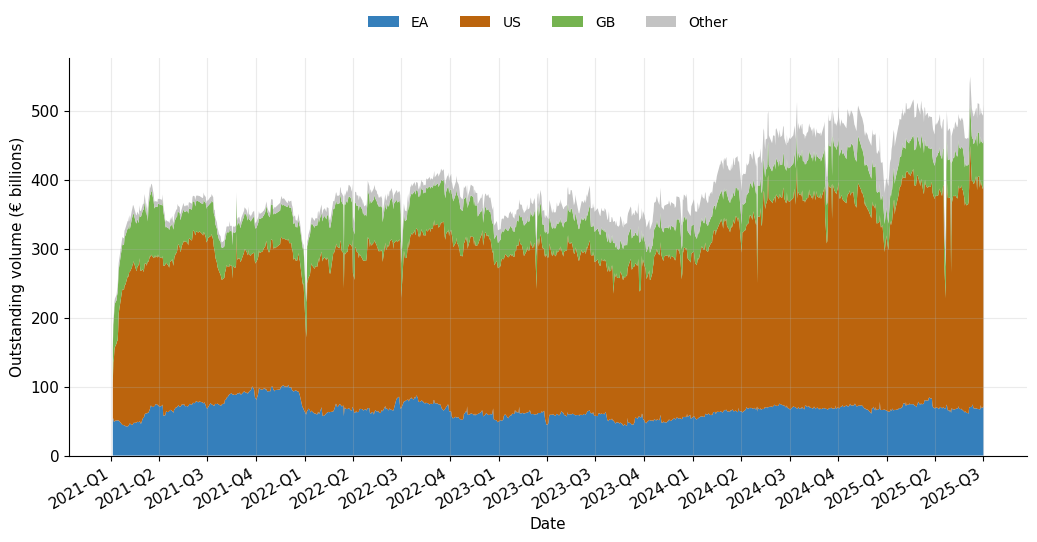

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- Prep ----------
df_plot = df.copy()
df_plot['business_date'] = pd.to_datetime(df_plot['business_date'])

wide = (
    df_plot.pivot_table(index='business_date', columns='incorporation', values='volume', aggfunc='sum')
           .fillna(0.0)
           .sort_index()
)

# Column order (adjusts automatically to what's present)
col_order = [c for c in ['EA', 'US', 'GB', 'Other'] if c in wide.columns]
wide = wide[col_order]

# ---------- Colors (distinct around your #2A78B8) ----------
colors = {
    'EA': '#2A78B8',  # main blue
    'US': '#B85C00',  # amber
    'GB': '#6EAF46',  # muted green
    'Other': '#C0C0C0'  # light grey
}
plot_colors = [colors[c] for c in col_order]

# ---------- Plot ----------
plt.rcParams.update({
    "figure.figsize": (10.5, 5.6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11
})

fig, ax = plt.subplots()

# Stacked area
ax.stackplot(wide.index, [wide[c].values for c in col_order],
             labels=col_order, colors=plot_colors, linewidth=0.8, alpha=0.95)

ax.set_xlabel("Date")
ax.set_ylabel("Outstanding volume (€ billions)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v/1e9:.0f}"))

# ---------- Quarterly x-axis (robust) ----------
# Build quarter tick positions and labels explicitly
start = wide.index.min().to_period('Q').start_time
end   = wide.index.max().to_period('Q').end_time
qticks = pd.date_range(start, end, freq='QS')  # Quarter Starts
qlabels = [f"{d.year}-Q{((d.month-1)//3)+1}" for d in qticks]

ax.set_xticks(qticks)
ax.set_xticklabels(qlabels, rotation=30, ha='right')

# Legend above
leg = ax.legend(ncol=len(col_order), frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.14))
for text in leg.get_texts():
    text.set_fontsize(10)

plt.tight_layout()
plt.show()


## USD

In [47]:
# Data prep
query = f""" 
WITH date_filter AS ( 
SELECT DISTINCT business_date
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
WHERE nominal_ccy = 'USD' 
AND business_date <= '2025-07-01' 
) 

SELECT s.business_date, SUM(nominal_value) as volume,
CASE 
    WHEN borrower_country_nationality IN ('US') OR lender_country_nationality IN ('US') THEN 'US'  
    WHEN borrower_country_nationality IN ('GB') OR lender_country_nationality IN ('GB') THEN 'GB'  
    WHEN borrower_country_nationality IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE', 'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') 
        AND lender_country_nationality IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE', 'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') THEN 'EA' 
    ELSE 'Other' 
END AS incorporation 
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s 
INNER JOIN date_filter d ON s.business_date = d.business_date 
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-07-01' 
AND nominal_ccy IN ('USD') 
AND intragroup = 1 
AND central_clearing = 'non-cleared'
AND security_isin IN {treasuries}
AND gnlcoll = 'SPEC'
GROUP BY s.business_date, incorporation
ORDER BY s.business_date, incorporation

""" 

df = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\4225827670.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, cnxn)


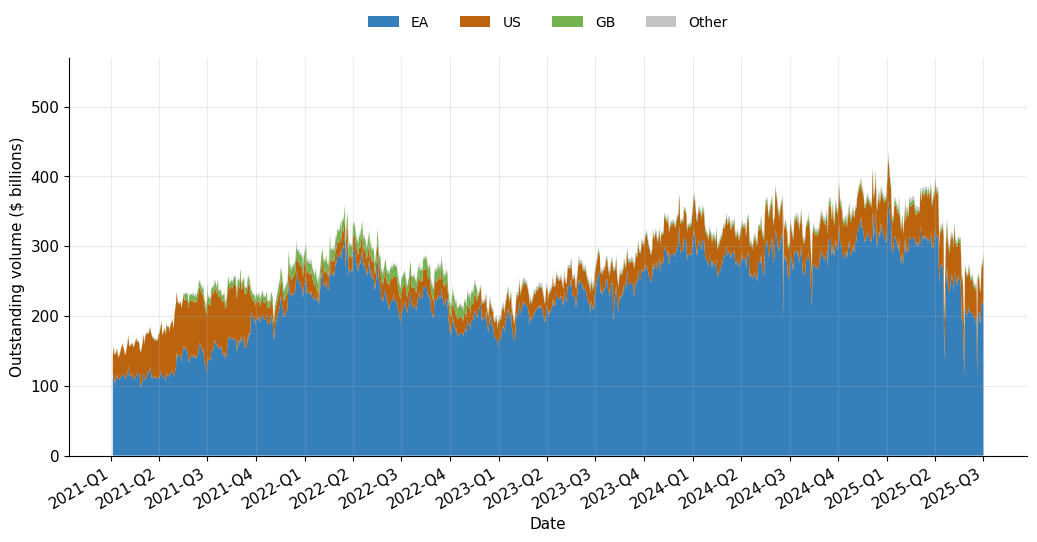

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- Prep ----------
df_plot = df.copy()
df_plot['business_date'] = pd.to_datetime(df_plot['business_date'])

wide = (
    df_plot.pivot_table(index='business_date', columns='incorporation', values='volume', aggfunc='sum')
           .fillna(0.0)
           .sort_index()
)

# Column order (adjusts automatically to what's present)
col_order = [c for c in ['EA', 'US', 'GB', 'Other'] if c in wide.columns]
wide = wide[col_order]

# ---------- Colors (distinct around your #2A78B8) ----------
colors = {
    'EA': '#2A78B8',  # main blue
    'US': '#B85C00',  # amber
    'GB': '#6EAF46',  # muted green
    'Other': '#C0C0C0'  # light grey
}
plot_colors = [colors[c] for c in col_order]

# ---------- Plot ----------
plt.rcParams.update({
    "figure.figsize": (10.5, 5.6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11
})

fig, ax = plt.subplots()

# Stacked area
ax.stackplot(wide.index, [wide[c].values for c in col_order],
             labels=col_order, colors=plot_colors, linewidth=0.8, alpha=0.95)

ax.set_xlabel("Date")
ax.set_ylabel("Outstanding volume ($ billions)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v/1e9:.0f}"))

# ---------- Quarterly x-axis (robust) ----------
# Build quarter tick positions and labels explicitly
start = wide.index.min().to_period('Q').start_time
end   = wide.index.max().to_period('Q').end_time
qticks = pd.date_range(start, end, freq='QS')  # Quarter Starts
qlabels = [f"{d.year}-Q{((d.month-1)//3)+1}" for d in qticks]

ax.set_xticks(qticks)
ax.set_xticklabels(qlabels, rotation=30, ha='right')
ax.set_ylim(0,570e9)

# Legend above
leg = ax.legend(ncol=len(col_order), frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.14))
for text in leg.get_texts():
    text.set_fontsize(10)

plt.tight_layout()
plt.show()

# Net positions

## EUR

In [49]:
# Data prep
query = f"""

SELECT s.business_date, 
CASE
    WHEN s.borrower_country_residence IN ('US') THEN 'US'
    WHEN s.borrower_country_residence IN ('GB') THEN 'UK'
    WHEN s.borrower_country_residence IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE',
          'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS residence_group, 
  sum(nominal_value)*-1 as borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-07-01'
AND nominal_ccy IN ('EUR')
AND central_clearing = 'non-cleared'
AND intragroup = 1
AND (
    (s.security_type = 'GOVS'
     AND LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.assttp_scty_issr_sector_riad = 'S1311')
    OR
    (LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.security_isin IN {unique_govs})
  )
GROUP BY business_date, residence_group
ORDER BY business_date, residence_group 


"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\1687387915.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [50]:
# Data prep
query = f"""


SELECT s.business_date, 
CASE
    WHEN s.lender_country_residence IN ('US') THEN 'US'
    WHEN s.lender_country_residence IN ('GB') THEN 'UK'
    WHEN s.lender_country_residence IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE',
          'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS residence_group, 
  sum(nominal_value) as lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-07-01'
AND nominal_ccy IN ('EUR')
AND central_clearing = 'non-cleared'
AND intragroup = 1
AND (
    (s.security_type = 'GOVS'
     AND LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.assttp_scty_issr_sector_riad = 'S1311')
    OR
    (LEFT(s.security_isin, 2) IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
     AND s.gnlcoll = 'SPEC'
     AND s.security_isin IN {unique_govs})
  )
GROUP BY business_date, residence_group
ORDER BY business_date, residence_group


"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\1691465716.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [51]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'residence_group'], how = 'outer')

In [52]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [53]:
df['borrowing_volume'].fillna(0,inplace=True)
df['lending_volume'].fillna(0,inplace=True)

In [54]:
df['net'] = (df['borrowing_volume'] + df['lending_volume'])/1e9

In [55]:
df.to_csv('Data\\breakdown_EUR.csv')

## USD

In [56]:
# Data prep
query = f"""

SELECT s.business_date, 
CASE
    WHEN s.borrower_country_residence IN ('US') THEN 'US'
    WHEN s.borrower_country_residence IN ('GB') THEN 'UK'
    WHEN s.borrower_country_residence IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE',
          'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS residence_group, 
  sum(nominal_value)*-1 as borrowing_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-07-01'
AND nominal_ccy IN ('USD')
AND central_clearing = 'non-cleared'
AND intragroup = 1
AND security_isin IN {treasuries}
AND gnlcoll = 'SPEC'
GROUP BY business_date, residence_group
ORDER BY business_date, residence_group 


"""

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\3192356292.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [57]:
# Data prep
query = f"""

SELECT s.business_date, 
CASE
    WHEN s.lender_country_residence IN ('US') THEN 'US'
    WHEN s.lender_country_residence IN ('GB') THEN 'UK'
    WHEN s.lender_country_residence IN
         ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE',
          'IT','LV','LT','LU','MT','NL','PT','SK','SI','ES')
      THEN 'Euro Area'
    ELSE 'Other'
  END AS residence_group, 
  sum(nominal_value) as lending_volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-07-01'
AND nominal_ccy IN ('USD')
AND central_clearing = 'non-cleared'
AND intragroup = 1
AND security_isin IN {treasuries}
AND gnlcoll = 'SPEC'
GROUP BY business_date, residence_group
ORDER BY business_date, residence_group


"""

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_17308\3200631997.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [58]:
df = df_borrowing.merge(df_lending, on= ['business_date', 'residence_group'], how = 'outer')

In [59]:
df['business_date'] = pd.to_datetime(df['business_date'])

In [60]:
df['borrowing_volume'].fillna(0,inplace=True)
df['lending_volume'].fillna(0,inplace=True)

In [61]:
df['net'] = (df['borrowing_volume'] + df['lending_volume'])/1e9

In [62]:
df.to_csv('Data\\breakdown_USD.csv')